In [1]:
# TITANIC CLASSIFICATION
# Decision Tree, kNN, Naive Bayes
# 5-Fold Cross Validation


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_validate
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score
)


# Load Data


In [3]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"

df = pd.read_csv(url)

print("Original Shape:")
print(df.shape)


Original Shape:
(891, 15)


# Select Features


In [4]:
df = df[[
    "survived",
    "pclass",
    "sex",
    "age",
    "fare"
]]

print("\nSelected Features:")
print(df.head())



Selected Features:
   survived  pclass     sex   age     fare
0         0       3    male  22.0   7.2500
1         1       1  female  38.0  71.2833
2         1       3  female  26.0   7.9250
3         1       1  female  35.0  53.1000
4         0       3    male  35.0   8.0500


# Handle Missing Values


In [5]:
df["age"] = df["age"].fillna(
    df["age"].mean()
)

# Convert Categorical Variables


In [6]:
encoder = LabelEncoder()

df["sex"] = encoder.fit_transform(
    df["sex"]
)

# male = 1
# female = 0


# Split X and y


In [7]:
X = df.drop("survived", axis=1)

y = df["survived"]

print("\nFeature Matrix Shape:")
print(X.shape)



Feature Matrix Shape:
(891, 4)


# Models


In [9]:
models = {
    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42,
            max_depth=4
        ),

    "kNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "Naive Bayes":
        GaussianNB()
}


# Evaluation Metrics


In [10]:
scoring = {
    "accuracy": "accuracy",

    "precision":
        make_scorer(
            precision_score
        ),

    "recall":
        make_scorer(
            recall_score
        ),

    "f1":
        make_scorer(
            f1_score
        )
}


# 5-Fold Cross Validation


In [11]:
results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=5,
        scoring=scoring
    )

    results.append({
        "Model": name,
        "Accuracy":
            scores["test_accuracy"].mean(),

        "Precision":
            scores["test_precision"].mean(),

        "Recall":
            scores["test_recall"].mean(),

        "F1":
            scores["test_f1"].mean()
    })

results_df = pd.DataFrame(results)

print("\nModel Performance")
print(results_df.round(4))



Model Performance
           Model  Accuracy  Precision  Recall      F1
0  Decision Tree    0.7902     0.7832  0.6318  0.6975
1            kNN    0.6903     0.6150  0.5381  0.5722
2    Naive Bayes    0.7677     0.7018  0.6845  0.6922


# Visualization of Results

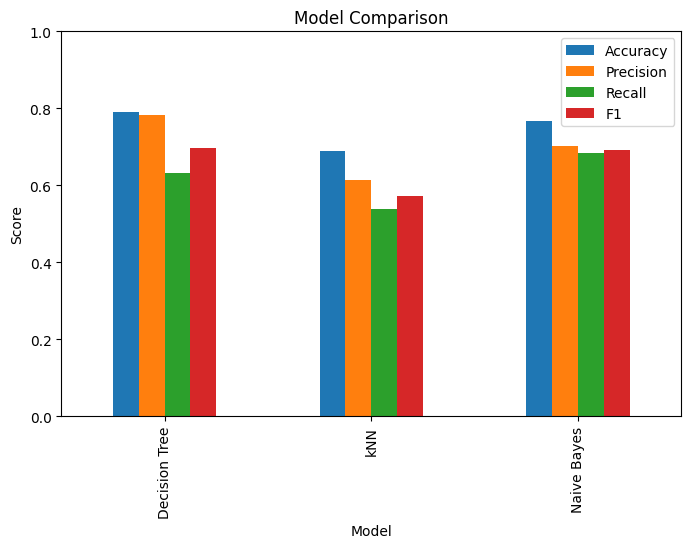

In [12]:
results_df.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0,1)

plt.show()


# Train Final Decision Tree

In [13]:
tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=4
)

tree_model.fit(X, y)

DecisionTreeClassifier(max_depth=4, random_state=42)

# Visualize Tree


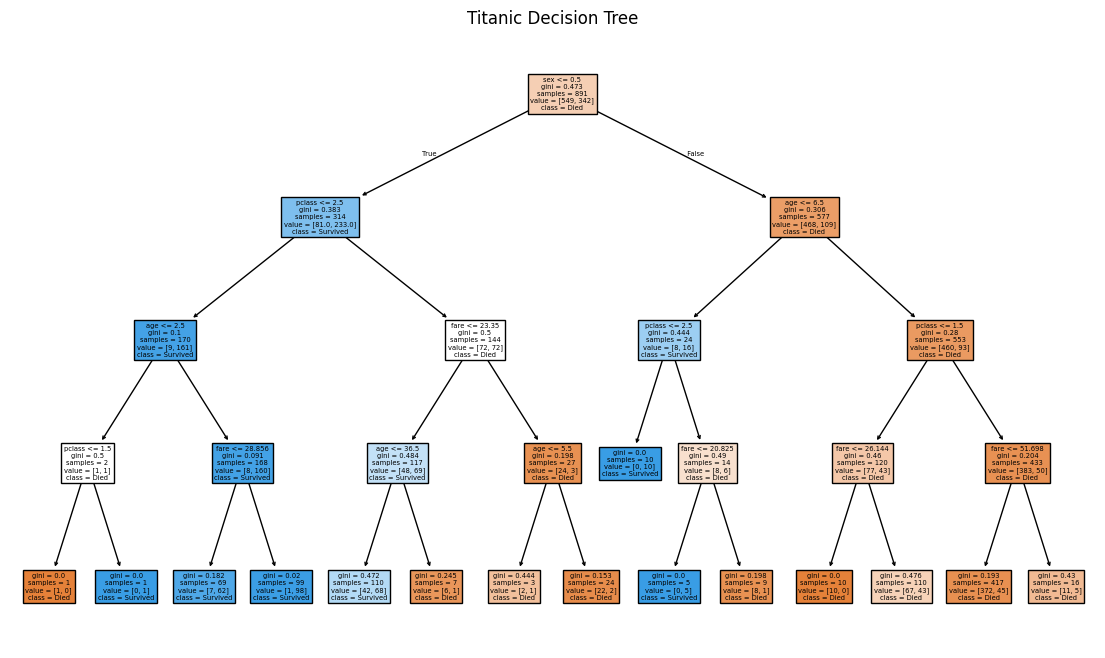

In [14]:

plt.figure(figsize=(14,8))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=[
        "Died",
        "Survived"
    ],
    filled=True
)

plt.title("Titanic Decision Tree")

plt.show()
